In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("/Users/sahilgulati/Desktop/Energy-Usage-Clustering-for-Cooling-Optimization/data/simulated_rack_data.csv", parse_dates=['timestamp'])
df.head()

,timestamp,rack_id,energy_watts,temperature_c
0,2025-06-29 17:59:23.076318,rack_1,299.053701,36.012187
1,2025-06-29 18:14:23.076318,rack_1,286.055564,34.727960
2,2025-06-29 18:29:23.076318,rack_1,276.554523,33.706574
3,2025-06-29 18:44:23.076318,rack_1,322.311888,32.964764
4,2025-06-29 18:59:23.076318,rack_1,290.528346,34.380754


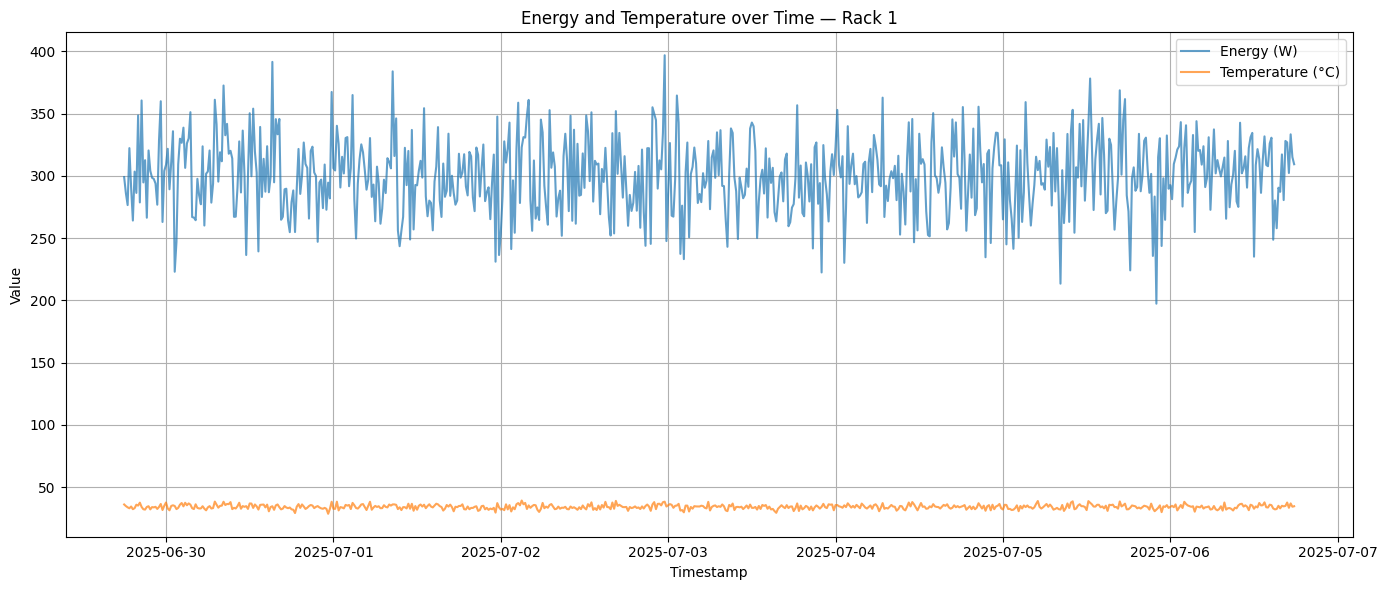

In [12]:
#filtering data just for rack 1
rack_sample = df[df['rack_id']=="rack_1"]
plt.figure(figsize=(14,6))
plt.plot(rack_sample['timestamp'], rack_sample['energy_watts'], label='Energy (W)', alpha=0.7)
plt.plot(rack_sample['timestamp'], rack_sample['temperature_c'], label='Temperature (°C)', alpha=0.7)
plt.title("Energy and Temperature over Time — Rack 1")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

# Group the data to get the mean energy and temperature per rack
rack_features = df.groupby('rack_id')[['energy_watts', 'temperature_c']].mean().reset_index()

# Save rack_id separately for labeling after clustering
rack_ids = rack_features['rack_id']

# Normalize the features using z-score normalization (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rack_features[['energy_watts', 'temperature_c']])


<Axes: >

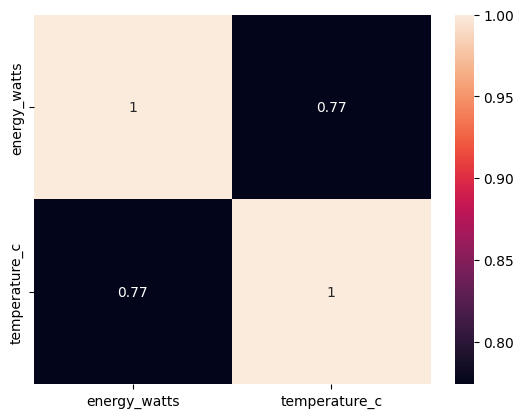

In [17]:
sns.heatmap(rack_features[['energy_watts', 'temperature_c']].corr(), annot=True)

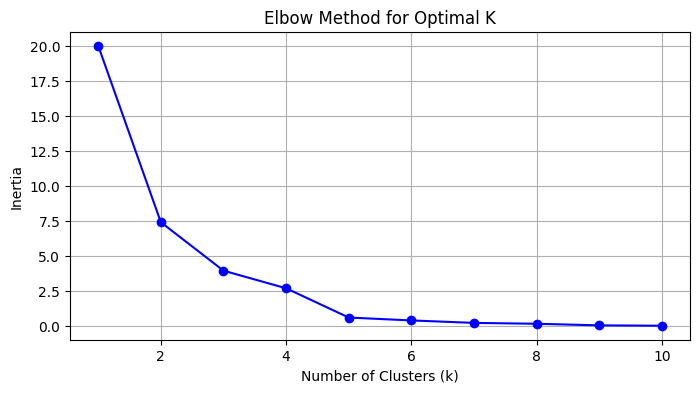

In [18]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1,11)

for k in K_range:
    Kmeans = KMeans(n_clusters = k, random_state=42)
    Kmeans.fit(X_scaled)
    inertia.append(Kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

In [19]:
K_optimal = 4
Kmeans = KMeans(n_clusters=K_optimal, random_state=42)
clusters = Kmeans.fit_predict(X_scaled)

rack_features['clusters'] = clusters

In [30]:
rack_features['cluster_name'] = rack_features['clusters'].map({
    0: 'High Energy & High Temp',
    1: 'Low Usage / Idle',
    2: 'Normal',
    3: 'Efficient Cooling'
})

In [37]:
rack_features['recommendation'] = rack_features['cluster_name'].map({
    'High Energy & High Temp': 'Check cooling or rebalance load',
    'Low Usage / Idle': ' Possibly power-save or decommission',
    'Normal': 'Operating normally',
    'Efficient Cooling': 'Consider design for other racks'
})


In [36]:
print(rack_features)

   rack_id  energy_watts  temperature_c  clusters             cluster_name  \
0   rack_1    300.368549      34.098841         2                   Normal   
1  rack_10    301.016004      33.328085         2                   Normal   
2   rack_2    232.555734      31.852992         2                   Normal   
3   rack_3    350.636102      33.870865         0  High Energy & High Temp   
4   rack_4    283.454542      32.529851         2                   Normal   
5   rack_5    330.352428      33.440539         0  High Energy & High Temp   
6   rack_6    298.017765      32.784976         2                   Normal   
7   rack_7    302.247205      30.048278         3        Efficient Cooling   
8   rack_8    328.562344      34.326935         0  High Energy & High Temp   
9   rack_9    208.557647      25.505180         1         Low Usage / Idle   

                          recommendation  
0                     Operating normally  
1                     Operating normally  
2           